# Verkettete Listen

## Agenda

1. Die Klassen `LinkedList` und `Node`  
2. Implementierung von `append`
3. Implementierung der Löschung
4. Bidirektionale Verbindungen (Doppelt verkettete Liste) & Sentinel-Kopf
5. Einbindung eines „Cursors“
6. Suche?
7. Laufzeitanalyse

## 1. Die Klassen `LinkedList` und `Node`

![](images/linked_list_visualization.png)

In [1]:
class LinkedList:
    class Node:
        def __init__(self, val, next=None):
            self.val = val
            self.next = next
    
    def __init__(self):
        self.head = None
        self.size = 0
    
    def prepend(self, value): # O(1)
        self.head = LinkedList.Node(value, self.head)
        self.size += 1
    
    def __len__(self):
        return self.size
        
    def __iter__(self):
        n = self.head
        while n:
            yield n.val
            n = n.next
    
    def __repr__(self):
        return '[' + ', '.join(repr(x) for x in self) + ']'

In [2]:
lst = LinkedList()
for i in range(10):
    lst.prepend(i)
lst

[9, 8, 7, 6, 5, 4, 3, 2, 1, 0]

## 2. Implementierung von `append`

### Option 1
Gehe die Liste durch und finde das letzte Element, füge dann das neue Element hinzu.

In [3]:
class LinkedList (LinkedList): # note: using inheritance to extend previous definition
    def append(self, value): # O(N) !!!!!!! <-- this is BAD
        if self.head:
            # step 1: find the last node
            n = self.head
            while n.next: # traverses all nodes in the list (O(N))
                n = n.next
            
            # step 2: make the last node refer to the newly created one
            n.next = LinkedList.Node(value)
            self.size += 1
        else:
            self.prepend(value)

In [4]:
lst = LinkedList()
for i in range(10):
    lst.append(i)
lst

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

### Option 2
Dem Schlangenkörper einen Schwanz hinzufügen

![](./images/linked_list_visualization_with_tail.png)

In [5]:
class LinkedList (LinkedList):
    def __init__(self):
        self.head = self.tail = None
        self.size = 0
        
    def prepend(self, value): # O(1)
        self.head = LinkedList.Node(value, next=self.head)

        if self.tail is None:
            self.tail = self.head
        
        self.size += 1
        
    def append(self, value): # O(1)
        if not self.tail:
            self.prepend(value)
        else:
            self.tail.next = self.tail = LinkedList.Node(value)
            self.size += 1

In [6]:
lst = LinkedList()
lst.prepend(1)
lst.prepend(2)
print(lst)
print(lst.tail.val)
for i in range(10):
    lst.append(i)
print(lst)
lst.tail.val

[2, 1]
1
[2, 1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


9

## 3. Implementierung der Löschung

### Löschen des Kopfes

In [7]:
class LinkedList (LinkedList):
    def del_head(self): # O(1)
        assert len(self) > 0
        self.head = self.head.next
        self.size -= 1

In [8]:
lst = LinkedList()
for i in range(10):
    lst.append(i)
lst.del_head()
lst.del_head()
lst

[2, 3, 4, 5, 6, 7, 8, 9]

### Löschen des Endes

In [9]:
class LinkedList (LinkedList):
    def del_tail(self): # O(N)
        assert len(self) > 0
        if self.head.next is None:
            # there is only one node
            self.head = self.tail = None
        else: 
            # we have at least two nodes

            # step 1: find the node previous to the tail
            n = self.head
            while n.next.next: # O(N)
                n = n.next
            
            # step 2: remove the last node and update the tail reference
            n.next = None
            self.tail = next
        
        self.size -= 1

In [10]:
lst = LinkedList()
for i in range(10):
    lst.append(i)
lst.del_tail()
lst.del_tail()
lst

[0, 1, 2, 3, 4, 5, 6, 7]

## 4. Bidirektionale Verbindungen (Doppelt verkettete Liste) & Sentinel-Kopf
Wir können das Löschen von Knoten etwas einfacher gestalten, wenn wir zusätzlich zum Nachfolger (`next`) noch den Vorgänger-Knoten ('previous`) speichern. Das führt zu einer doppelten Verkettung.
Dann können wir uns die Sonderfälle noch etwas vereinfachen in dem wir einen Wächter-Knoten (Sentinel-Head) ohne Daten hinzunehmen.

![](./images/doubly_linked_circular_list_with_sentinel.png)

In [11]:
class LinkedList:
    class Node:
        def __init__(self, val, previous=None, next=None):
            self.val = val
            self.previous = previous
            self.next  = next
    
    def __init__(self):
        self.size = 0
        self.head = LinkedList.Node(None) # sentinel node -- not element containing!
        self.head.previous = self.head.next = self.head
        
    def prepend(self, value): # O(1)
        self.size += 1
        n = LinkedList.Node(value, previous=self.head, next=self.head.next)
        self.head.next.previous = n
        self.head.next = n
        
    def append(self, value): # O(1)
        self.size += 1
        n = LinkedList.Node(value, previous=self.head.previous, next=self.head)
        self.head.previous.next = n
        self.head.previous = n
        
    def __getitem__(self, idx): # O(N) 
        assert idx >= 0 and idx < len(self)
        n = self.head.next
        for _ in range(idx):
            n = n.next
        return n.val
        
    def __len__(self):
        return self.size
        
    def __iter__(self):
        n = self.head.next
        while n is not self.head:
            yield n.val
            n = n.next
    
    def __repr__(self):
        return '[' + ', '.join(str(x) for x in self) + ']'

In [12]:
lst = LinkedList()
for i in range(10):
    lst.prepend(i)
for i in range(10):
    lst.append(i)
lst

[9, 8, 7, 6, 5, 4, 3, 2, 1, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

## 5. Einfügen eines „Cursors“

In [13]:
class LinkedList:
    class Node:
        def __init__(self, val, previous=None, next=None):
            self.val = val
            self.previous = previous
            self.next  = next
    
    def __init__(self):
        self.head = self.cursor = LinkedList.Node(None)
        self.head.previous = self.head.next = self.head
        self.size = 0
                
    def append(self, value):
        n = LinkedList.Node(value, previous=self.head.previous, next=self.head)
        n.previous.next = n.next.previous = n
        self.size += 1

    def __getitem__(self, idx):
        assert idx >= 0 and idx < len(self)
        n = self.head.next
        for _ in range(idx):
            n = n.next
        return n.val
        
    def cursor_set(self, idx):
        assert idx >= 0 and idx < len(self)
        self.cursor = self.head.next
        for _ in range(idx):
            self.cursor = self.cursor.next
    
    def cursor_insert(self, value): # O(1)
        assert self.cursor is not self.head
        n = LinkedList.Node(value, previous=self.cursor.previous, next=self.cursor)
        n.previous.next = n.next.previous = n
        self.size += 1
    
    def cursor_delete(self): # O(1)
        assert self.cursor is not self.head
        n = self.cursor 
        self.cursor = self.cursor.next
        n.previous.next = n.next
        n.next.previous = n.previous
        self.size -= 1
        
    def __len__(self):
        return self.size
        
    def __iter__(self):
        n = self.head.next
        while n is not self.head:
            yield n.val
            n = n.next
    
    def __repr__(self):
        return '[' + ', '.join(str(x) for x in self) + ']'

In [14]:
lst = LinkedList()
for i in range(10):
    lst.append(i)
lst

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [15]:
lst.cursor_set(4)
for x in 'abcd':
    lst.cursor_insert(x)
lst

[0, 1, 2, 3, a, b, c, d, 4, 5, 6, 7, 8, 9]

In [16]:
lst.cursor_set(8)
for _ in range(4):
    lst.cursor_delete()
lst

[0, 1, 2, 3, a, b, c, d, 8, 9]

## 6. Suche?

Lineare Suche mit $O(N)$ ist die einzige Option, wenn die Liste unsortiert ist, aber wir haben zuvor die binäre Suche implementiert, die bei einer sortierten Liste als Eingabe in $O(\log N)$ Zeit läuft.

Lässt sich das auf verkettete Listen übertragen?

In [17]:
def contains(lst, x):
    lo = 0
    hi = len(lst)-1
    while lo <= hi: 
        mid = (lo + hi) // 2
        if x < lst[mid]:
            hi = mid - 1
        elif x > lst[mid]:
            lo = mid + 1
        else:
            return True
    else:
        return False

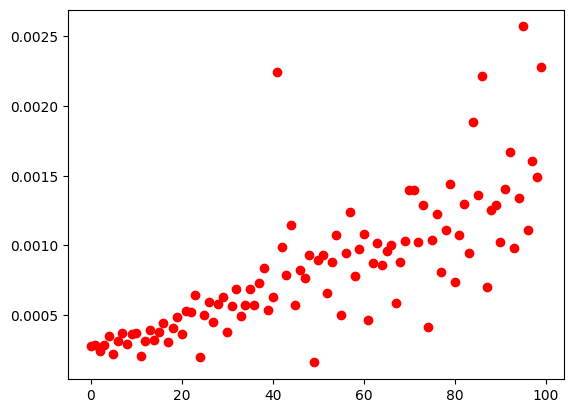

In [18]:
import timeit
import matplotlib.pyplot as plt
import numpy as np

# runtimes when searching for different values in a fixed-size list

def build_sorted_llist(n):
    lst = LinkedList()
    for x in range(n):
        lst.append(x)
    return lst
    
ts = [timeit.timeit(stmt=f'contains(lst, {x})', 
                    setup='lst = build_sorted_llist(100)',
                    globals=globals(), 
                    number=100)
      for x in range(100)]

plt.plot(range(100), ts, 'or');

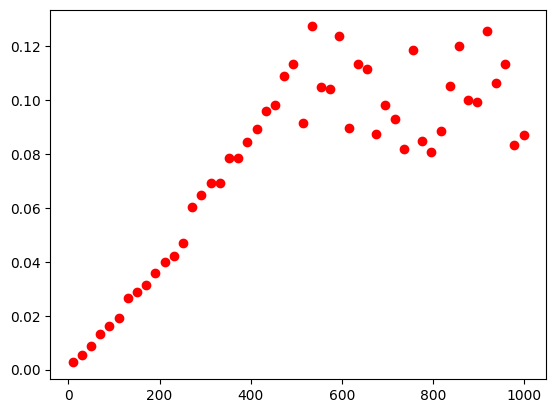

In [19]:
# runtimes when searching for an edge-value in lists of increasing size

ns = np.linspace(10, 1000, 50, dtype=int)
ts = [timeit.timeit('contains(lst, 500)', 
                    setup=f'lst=build_sorted_llist({n})',
                    globals=globals(),
                    number=1000)
      for n in ns]

plt.plot(ns, ts, 'or');

## 7. Laufzeitanalyse

Laufzeitkomplexitäten für eine zirkuläre, doppelt verkettete Liste mit $N$ Elementen:

- Indexierung (positionsbasierter Zugriff) = $O(N)$
- Suche (unsortiert) = $O(N)$
- Suche (sortiert) = $O(N)$ -- binäre Suche funktioniert nicht.
- Einfügen am Anfang (Prepend) = $O(1)$
- Einfügen am Ende (Append) = $O(1)$
- Einfügen (an beliebiger Position): Indexierung ($O(N)$) + Einfügen ($O(1)$) = $O(N)$
- Löschen (an beliebiger Position): Indexierung ($O(N)$) + Löschen ($O(1)$) = $O(N)$